# Numerical Linear Algebra — Notebook 3: Conditioning and Stability

**Topics covered:** Condition Numbers · Floating Point Arithmetic · Stability

**Prerequisites:** Notebooks 1 and 2.


In [1]:
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

np.random.seed(0)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 12,
                     'axes.spines.top': False, 'axes.spines.right': False})


---
## 1. Condition Numbers

### Motivation

A condition number measures the sensitivity of the output of a mathematical problem
to small perturbations in its input.
A large condition number means the problem is **ill-conditioned**: small input errors
become large output errors. This is a property of the problem, not the algorithm.

### Definition

The **condition number** of a nonsingular $A \in \mathbb{R}^{n \times n}$ in the $p$-norm is:

$$\kappa_p(A) = \|A\|_p \|A^{-1}\|_p \ge 1.$$

For the 2-norm:

$$\kappa_2(A) = \frac{\sigma_{\max}(A)}{\sigma_{\min}(A)}.$$

### Perturbation Bound for $Ax = b$

If $A(x + \delta x) = b + \delta b$ and $A$ is nonsingular:

$$\frac{\|\delta x\|_p}{\|x\|_p} \le \kappa_p(A)\, \frac{\|\delta b\|_p}{\|b\|_p}.$$

For perturbations to $A$: if $(A + \delta A)(x + \delta x) = b$, then:

$$\frac{\|\delta x\|_p}{\|x + \delta x\|_p} \le \kappa_p(A)\, \frac{\|\delta A\|_p}{\|A\|_p}.$$

**Key interpretation:** $\kappa(A)$ is the factor by which relative errors in the data can be amplified.
If $\kappa(A) \approx 10^k$, we lose about $k$ decimal digits of accuracy.


In [2]:
# Condition number experiments on the Hilbert matrix (notoriously ill-conditioned)
def hilbert(n):
    return np.array([[1.0 / (i + j + 1) for j in range(n)] for i in range(n)])

print(f"{'n':>4}  {'kappa_2(H_n)':>20}  {'Expected digits lost':>22}")
print("-" * 52)
for n in range(2, 13):
    H = hilbert(n)
    kappa = np.linalg.cond(H)
    lost  = np.log10(kappa)
    print(f"{n:4d}  {kappa:20.4e}  {lost:22.2f}")


   n          kappa_2(H_n)    Expected digits lost
----------------------------------------------------
   2            1.9281e+01                    1.29
   3            5.2406e+02                    2.72
   4            1.5514e+04                    4.19
   5            4.7661e+05                    5.68
   6            1.4951e+07                    7.17
   7            4.7537e+08                    8.68
   8            1.5258e+10                   10.18
   9            4.9315e+11                   11.69
  10            1.6025e+13                   13.20
  11            5.2202e+14                   14.72
  12            1.6212e+16                   16.21


In [3]:
# Perturbation experiment: Ax = b with Hilbert matrix
n = 10
H = hilbert(n)
x_true = np.ones(n)
b = H @ x_true

kappa = np.linalg.cond(H)
print(f"H_10 condition number: {kappa:.4e}")
print(f"Machine epsilon:       {np.finfo(float).eps:.4e}")
print()

# Perturb b by eps-level noise and solve
n_trials = 1000
rel_errs_x, rel_errs_b = [], []
for _ in range(n_trials):
    db = np.finfo(float).eps * np.linalg.norm(b) * np.random.randn(n)
    bp = b + db
    xp = np.linalg.solve(H, bp)
    rel_errs_x.append(np.linalg.norm(xp - x_true) / np.linalg.norm(x_true))
    rel_errs_b.append(np.linalg.norm(db) / np.linalg.norm(b))

print(f"Mean relative perturbation in b: {np.mean(rel_errs_b):.2e}")
print(f"Mean relative error in x:        {np.mean(rel_errs_x):.2e}")
print(f"Amplification factor observed:   {np.mean(rel_errs_x) / np.mean(rel_errs_b):.2e}")
print(f"kappa(H_10):                     {kappa:.2e}")
print()
print(f"The perturbation bound predicts amplification up to kappa = {kappa:.2e},")
print(f"which can completely destroy the solution for machine-epsilon perturbations.")


H_10 condition number: 1.6025e+13
Machine epsilon:       2.2204e-16

Mean relative perturbation in b: 6.77e-16
Mean relative error in x:        2.44e-03
Amplification factor observed:   3.60e+12
kappa(H_10):                     1.60e+13

The perturbation bound predicts amplification up to kappa = 1.60e+13,
which can completely destroy the solution for machine-epsilon perturbations.


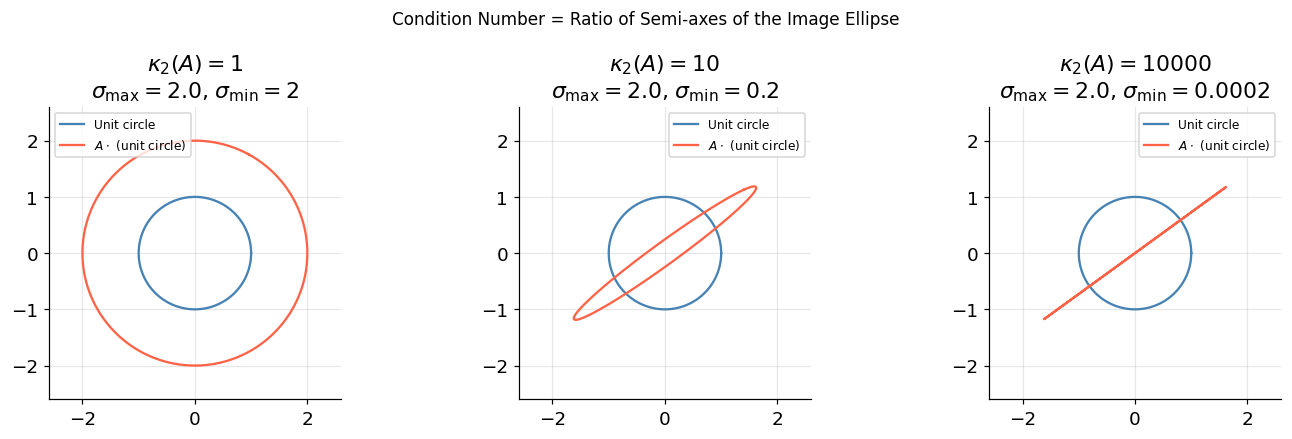

In [4]:
# Geometric interpretation: condition number via singular values
np.random.seed(4)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
kappas_geo = [1, 10, 1e4]

t = np.linspace(0, 2*np.pi, 400)
unit_circle = np.vstack([np.cos(t), np.sin(t)])

for ax, kappa_g in zip(axes, kappas_geo):
    sv1 = 2.0
    sv2 = sv1 / kappa_g
    theta = np.pi / 5
    Q1 = np.array([[np.cos(theta), -np.sin(theta)],
                   [np.sin(theta),  np.cos(theta)]])
    theta2 = np.pi / 7
    Q2 = np.array([[np.cos(theta2), -np.sin(theta2)],
                   [np.sin(theta2),  np.cos(theta2)]])
    A = Q1 @ np.diag([sv1, sv2]) @ Q2

    image = A @ unit_circle
    ax.plot(*unit_circle, 'steelblue', lw=1.5, label='Unit circle')
    ax.plot(*image, 'tomato', lw=1.5, label=r'$A \cdot$ (unit circle)')
    ax.set_aspect('equal')
    title_line1 = fr'$\kappa_2(A) = {kappa_g:.0f}$'
    title_line2 = fr'$\sigma_{{\max}}={sv1:.1f}$, $\sigma_{{\min}}={sv2:.2g}$'
    ax.set_title(title_line1 + '\n' + title_line2)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    lim = sv1 * 1.3
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)

plt.suptitle('Condition Number = Ratio of Semi-axes of the Image Ellipse', fontsize=11)
plt.tight_layout()
plt.show()


---
## 2. Floating Point Arithmetic

### The IEEE 754 Standard

Every floating-point number in the double-precision standard (binary64) has the form:

$$x = \pm m \cdot 2^{e}, \quad m \in [1, 2) \text{ (normalized mantissa)}, \quad e \in [-1022, 1023].$$

The **precision** is $t = 52$ binary digits (plus the implicit leading 1), giving 53 significant bits.

### Machine Epsilon

$\varepsilon_{\text{mach}}$ is the smallest positive floating-point number $\varepsilon$ such that $\operatorname{fl}(1 + \varepsilon) > 1$:

$$\varepsilon_{\text{mach}} = 2^{-52} \approx 2.22 \times 10^{-16}.$$

### Fundamental Axiom of Floating-Point Arithmetic

For any floating-point $x, y$ and operation $\circ \in \{+, -, \times, \div\}$:

$$\operatorname{fl}(x \circ y) = (x \circ y)(1 + \delta), \quad |\delta| \le \varepsilon_{\text{mach}}.$$

Every elementary operation introduces a relative error of at most $\varepsilon_{\text{mach}}$.

### Catastrophic Cancellation

When two nearly equal numbers are subtracted, leading significant digits cancel,
and the relative error in the result can be enormous.

**Example:** $f(x) = \sqrt{x+1} - \sqrt{x}$ for large $x$.
As $x \to \infty$, the exact value $f(x) = 1/(\sqrt{x+1} + \sqrt{x}) \to 0$, but
the naive computation subtracts two large, nearly equal quantities.

Stable reformulation: $f(x) = 1 / (\sqrt{x+1} + \sqrt{x})$.


In [5]:
# Machine epsilon
eps_numpy  = np.finfo(float).eps
eps_manual = 1.0
while 1.0 + eps_manual / 2 > 1.0:
    eps_manual /= 2

print(f"Machine epsilon (np.finfo): {eps_numpy:.20e}")
print(f"Machine epsilon (computed): {eps_manual:.20e}")
print(f"Equal: {np.isclose(eps_numpy, eps_manual)}")
print()

# Rounding demonstration
a = 1.0
b = eps_numpy / 2    # just below machine epsilon
print(f"1 + eps_mach/2 == 1:  {a + b == a}")
print(f"1 + eps_mach   > 1:   {a + eps_numpy > a}")


Machine epsilon (np.finfo): 2.22044604925031308085e-16
Machine epsilon (computed): 2.22044604925031308085e-16
Equal: True

1 + eps_mach/2 == 1:  True
1 + eps_mach   > 1:   True


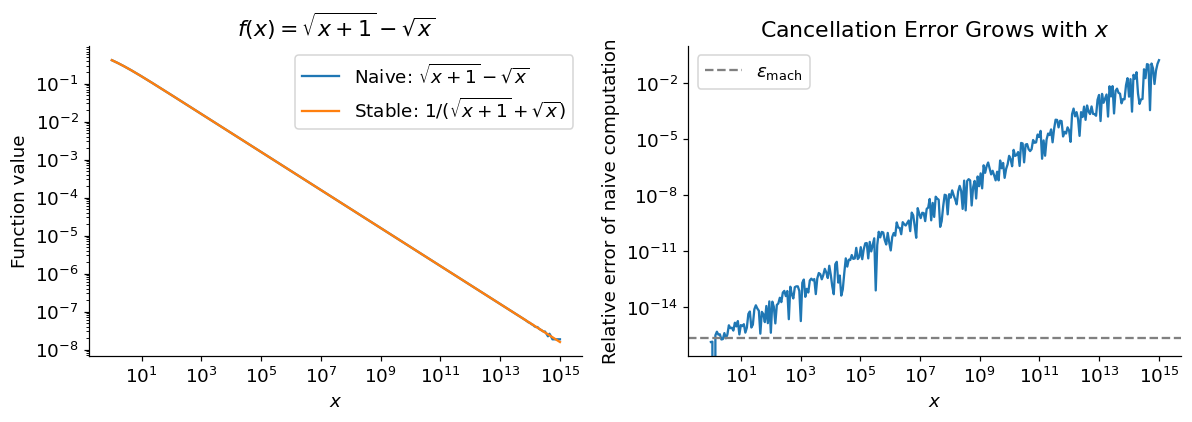

For x = 1e14:
  Naive:  5.0291419029235840e-08
  Stable: 4.9999999999999872e-08


In [6]:
# Catastrophic cancellation: sqrt(x+1) - sqrt(x)
x_vals = np.logspace(0, 15, 300)

f_naive  = np.sqrt(x_vals + 1) - np.sqrt(x_vals)
f_stable = 1.0 / (np.sqrt(x_vals + 1) + np.sqrt(x_vals))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].loglog(x_vals, np.abs(f_naive),  label=r'Naive: $\sqrt{x+1} - \sqrt{x}$')
axes[0].loglog(x_vals, np.abs(f_stable), label=r'Stable: $1/(\sqrt{x+1}+\sqrt{x})$')
axes[0].set_xlabel('$x$')
axes[0].set_ylabel('Function value')
axes[0].set_title(r'$f(x) = \sqrt{x+1} - \sqrt{x}$')
axes[0].legend()

# Relative error of naive vs stable
rel_err = np.abs(f_naive - f_stable) / np.abs(f_stable)
axes[1].loglog(x_vals, rel_err)
axes[1].axhline(np.finfo(float).eps, ls='--', color='gray', label=r'$\varepsilon_{\rm mach}$')
axes[1].set_xlabel('$x$')
axes[1].set_ylabel('Relative error of naive computation')
axes[1].set_title('Cancellation Error Grows with $x$')
axes[1].legend()

plt.tight_layout()
plt.show()

print("For x = 1e14:")
xbig = 1e14
print(f"  Naive:  {np.sqrt(xbig+1) - np.sqrt(xbig):.16e}")
print(f"  Stable: {1.0 / (np.sqrt(xbig+1) + np.sqrt(xbig)):.16e}")


In [7]:
# More cancellation examples
print("=== Catastrophic cancellation examples ===")
print()

# (1) Quadratic formula: x^2 - large*x + 1 = 0 for large coefficients
a_coef, b_coef, c_coef = 1.0, -1e8, 1.0
disc = np.sqrt(b_coef**2 - 4*a_coef*c_coef)
x1_naive = (-b_coef + disc) / (2*a_coef)
x2_naive = (-b_coef - disc) / (2*a_coef)
# Stable: compute larger root first, then use Vieta: x1 * x2 = c/a
x1_stable = (-b_coef + disc) / (2*a_coef)
x2_stable = c_coef / (a_coef * x1_stable)

print(f"Quadratic x^2 - 1e8 x + 1 = 0 (smaller root):")
print(f"  Naive:  x2 = {x2_naive:.10e}")
print(f"  Stable: x2 = {x2_stable:.10e}")

# (2) exp(x) - 1 for small x
x_small = 1e-15
print(f"\nexp(x) - 1 for x = {x_small}:")
print(f"  Naive:  {np.exp(x_small) - 1:.16e}")
print(f"  Stable (np.expm1): {np.expm1(x_small):.16e}")

# (3) log(1+x) for small x
print(f"\nlog(1+x) for x = {x_small}:")
print(f"  Naive:  {np.log(1 + x_small):.16e}")
print(f"  Stable (np.log1p): {np.log1p(x_small):.16e}")


=== Catastrophic cancellation examples ===

Quadratic x^2 - 1e8 x + 1 = 0 (smaller root):
  Naive:  x2 = 7.4505805969e-09
  Stable: x2 = 1.0000000000e-08

exp(x) - 1 for x = 1e-15:
  Naive:  1.1102230246251565e-15
  Stable (np.expm1): 1.0000000000000005e-15

log(1+x) for x = 1e-15:
  Naive:  1.1102230246251559e-15
  Stable (np.log1p): 9.9999999999999968e-16


---
## 3. Stability

### Definitions

Let $f : \mathcal{X} \to \mathcal{Y}$ be the problem to solve, and let $\tilde{f}$ be the
computed (floating-point) approximation.

**Forward error:** $\|\tilde{f}(x) - f(x)\|$ — how far is the computed answer from the true answer?

**Backward error:** The smallest $\|\delta x\|$ such that $\tilde{f}(x) = f(x + \delta x)$ — 
what input perturbation would make our computed answer exact?

**Backward stable algorithm:** An algorithm for which the backward error satisfies:

$$\frac{\|\delta x\|}{\|x\|} = O(\varepsilon_{\text{mach}}).$$

### The Accuracy Bound

For a backward stable algorithm:

$$\text{Forward error} \lesssim \kappa(f) \cdot \varepsilon_{\text{mach}},$$

where $\kappa(f)$ is the condition number of the problem $f$.

This separates two independent sources of error:
- **Conditioning** (intrinsic to the problem, unavoidable)
- **Stability** (a property of the algorithm, controllable)

### Key Examples

| Algorithm | Backward stable? | Notes |
|---|---|---|
| Householder QR | Yes | Gold standard for QR |
| Modified Gram-Schmidt | Not fully, but nearly | Acceptable in practice |
| Classical Gram-Schmidt | No | Can completely lose orthogonality |
| Gaussian elimination with partial pivoting | Yes in practice | Worst-case growth is $2^{n-1}$ but rare |
| Gaussian elimination without pivoting | No | Can fail on well-conditioned problems |
| Cholesky (for SPD) | Yes | No pivoting needed |


In [8]:
# Backward error illustration: solving a linear system
np.random.seed(9)
n = 6
A = np.random.randn(n, n)
x_true = np.random.randn(n)
b = A @ x_true

# Solve with numpy (uses LAPACK dgesv = LU with partial pivoting)
x_comp = np.linalg.solve(A, b)

fwd_err = np.linalg.norm(x_comp - x_true) / np.linalg.norm(x_true)
# Backward error: smallest delta_A or delta_b such that (A + delta_A) x_comp = b + delta_b
# Here: backward error in b only: ||A x_comp - b|| / ||b||
bwd_err = np.linalg.norm(A @ x_comp - b) / np.linalg.norm(b)
kappa_A = np.linalg.cond(A)

print(f"Condition number of A:  kappa(A) = {kappa_A:.4e}")
print(f"Machine epsilon:        eps_mach  = {np.finfo(float).eps:.4e}")
print()
print(f"Backward error (residual relative): {bwd_err:.4e}")
print(f"Forward error  (relative):          {fwd_err:.4e}")
print(f"Predicted forward error (kappa * eps): {kappa_A * np.finfo(float).eps:.4e}")
print()
print(f"LAPACK solve: backward error ~= eps_mach (backward stable).")
print(f"Forward error ~= kappa * eps_mach (cannot do better for this problem).")


Condition number of A:  kappa(A) = 2.5657e+01
Machine epsilon:        eps_mach  = 2.2204e-16

Backward error (residual relative): 1.3302e-16
Forward error  (relative):          3.1775e-16
Predicted forward error (kappa * eps): 5.6970e-15

LAPACK solve: backward error ~= eps_mach (backward stable).
Forward error ~= kappa * eps_mach (cannot do better for this problem).


In [9]:
# Distinguish ill-conditioning from instability
# Case 1: Ill-conditioned problem, stable algorithm -> large forward error is unavoidable
# Case 2: Well-conditioned problem, unstable algorithm (no pivoting) -> avoidable large error

def lu_no_pivot(A):
    'LU factorization without pivoting (potentially unstable).'
    n = A.shape[0]
    L = np.eye(n)
    U = A.copy().astype(float)
    for k in range(n-1):
        if abs(U[k, k]) < 1e-15:
            raise ValueError("Zero pivot encountered.")
        for i in range(k+1, n):
            L[i, k] = U[i, k] / U[k, k]
            U[i, k:] -= L[i, k] * U[k, k:]
    return L, U

# Construct a matrix that requires pivoting: element growth without it
# Classic example: Wilkinson-type matrix
n = 8
W = np.eye(n)
for i in range(n-1):
    W[i+1:, i] = -1.0
W[:, n-1] = 1.0

x_true = np.random.randn(n)
b = W @ x_true

# Solve with and without pivoting
x_np  = np.linalg.solve(W, b)
P, L_piv, U_piv = la.lu(W)
x_piv = np.linalg.solve(U_piv, np.linalg.solve(L_piv, P.T @ b))

try:
    L_np, U_np = lu_no_pivot(W)
    x_nopiv = np.linalg.solve(U_np, np.linalg.solve(L_np, b))
    err_nopiv = np.linalg.norm(x_nopiv - x_true) / np.linalg.norm(x_true)
except Exception as e:
    err_nopiv = float('nan')
    print(f"No-pivot LU failed: {e}")

print(f"kappa(W_Wilkinson, n=8): {np.linalg.cond(W):.2e}")
print(f"Relative error with    pivoting: {np.linalg.norm(x_piv - x_true)/np.linalg.norm(x_true):.2e}")
print(f"Relative error without pivoting: {err_nopiv:.2e}")


kappa(W_Wilkinson, n=8): 3.51e+00
Relative error with    pivoting: 1.54e-15
Relative error without pivoting: 1.54e-15


In [10]:
# Stability of QR vs normal equations on ill-conditioned A
np.random.seed(22)
n_cond = 8
kappa_ls = 1e7
A_ill = build_ill_conditioned = lambda m, n, k: (
    lambda U, s, V: (U * s) @ V.T)(
        *[x for x in [np.linalg.qr(np.random.randn(m, n))[0],
                       np.logspace(0, -np.log10(k), n),
                       np.linalg.qr(np.random.randn(n, n))[0]]])

m_ls = 40
A_ls = build_ill_conditioned(m_ls, n_cond, kappa_ls)
x_ls_true = np.random.randn(n_cond)
b_ls = A_ls @ x_ls_true + 1e-8 * np.random.randn(m_ls)   # tiny noise

x_ne  = np.linalg.solve(A_ls.T @ A_ls, A_ls.T @ b_ls)
Q_ls, R_ls = np.linalg.qr(A_ls, mode='reduced')
x_qr_ls = la.solve_triangular(R_ls, Q_ls.T @ b_ls, lower=False)

print(f"Least squares test: m={m_ls}, n={n_cond}, kappa(A) ~ {kappa_ls:.0e}")
print(f"  kappa(A^T A) ~ {np.linalg.cond(A_ls.T @ A_ls):.2e}")
print()
print(f"  Normal equations error: {np.linalg.norm(x_ne   - x_ls_true):.2e}")
print(f"  QR method error:        {np.linalg.norm(x_qr_ls - x_ls_true):.2e}")


Least squares test: m=40, n=8, kappa(A) ~ 1e+07
  kappa(A^T A) ~ 9.97e+13

  Normal equations error: 1.07e-02
  QR method error:        9.26e-03


---
## Section Summary

| Concept | Key Message |
|---|---|
| Condition number | Property of the **problem**: $\kappa(A) = \sigma_{\max}/\sigma_{\min}$ |
| Floating-point error | Every elementary op has relative error $\le \varepsilon_{\text{mach}} \approx 2.2 \times 10^{-16}$ |
| Catastrophic cancellation | Subtraction of nearly equal quantities: always reformulate to avoid it |
| Backward stability | Property of the **algorithm**: computes the exact answer to a slightly perturbed problem |
| Forward error bound | $\text{forward error} \lesssim \kappa \cdot \varepsilon_{\text{mach}}$ for backward-stable algorithms |

**The golden rule:** A backward-stable algorithm on a well-conditioned problem produces accurate results.
Large errors arise from either ill-conditioning (unavoidable) or an unstable algorithm (avoidable).
